In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/musait/Dataset/Small/Test/neutral/neutral6.jpg
/kaggle/input/musait/Dataset/Small/Test/neutral/neutral12.jpg
/kaggle/input/musait/Dataset/Small/Test/neutral/neutral7.jpg
/kaggle/input/musait/Dataset/Small/Test/neutral/neutral15.jpg
/kaggle/input/musait/Dataset/Small/Test/neutral/neutral2.jpg
/kaggle/input/musait/Dataset/Small/Test/neutral/neutral11.jpg
/kaggle/input/musait/Dataset/Small/Test/neutral/neutral8.jpg
/kaggle/input/musait/Dataset/Small/Test/neutral/neutral14.jpg
/kaggle/input/musait/Dataset/Small/Test/neutral/neutral1.jpg
/kaggle/input/musait/Dataset/Small/Test/neutral/neutral10.jpg
/kaggle/input/musait/Dataset/Small/Test/neutral/neutral4.jpg
/kaggle/input/musait/Dataset/Small/Test/neutral/neutral13.jpg
/kaggle/input/musait/Dataset/Small/Test/neutral/neutral5.jpg
/kaggle/input/musait/Dataset/Small/Test/neutral/neutral3.jpg
/kaggle/input/musait/Dataset/Small/Test/neutral/neutral9.jpg
/kaggle/input/musait/Dataset/Small/Test/negative/negative1.jpg
/kaggle/input/mu

In [ ]:
# ======================= #
#  STEP 0: INSTALLATION   #
# ======================= #
!pip install torch torchvision scikit-learn matplotlib

import os
os.kill(os.getpid(), 9)  # Restart runtime after installing

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 93.3 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 78.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 87.4 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5

In [1]:
# ======================= #
#     STEP 1: IMPORTS     #
# ======================= #
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import Dataset, DataLoader, random_split

import os
from PIL import Image
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import json

In [2]:
# ============================== #
# STEP 2: DEFINE MAPPINGS        #
# ============================== #
# 8-emotion → 3 sentiment mapping
emotion_to_sentiment = {
    "amusement": "positive",
    "contentment": "positive",
    "excitement": "positive",
    "awe": "neutral",
    "anger": "negative",
    "disgust": "negative",
    "fear": "negative",
    "sadness": "negative"
}


In [3]:
# ================================= #
# STEP 3: DATASET CLASS (CSV-based) #
# ================================= #
class EmoNetDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform
        self.classes = sorted(self.data['label'].unique())
        self.class_to_idx = {label: idx for idx, label in enumerate(self.classes)}
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.data.iloc[idx, 0])
        image = Image.open(img_path).convert('RGB')
        label = self.class_to_idx[self.data.iloc[idx, 1]]
        
        if self.transform:
            image = self.transform(image)
        
        return image, label


In [7]:
import os

temp_data = pd.DataFrame(columns=["filename","label"])
all_files = os.listdir("/kaggle/input/musait/basket")
all_files.sort()

for file in all_files:
    label = file.split("_")[0]
    # print(label)
    # print(file)
    temp_data = pd.concat([temp_data, pd.DataFrame([[file, label]], columns=["filename", "label"])], ignore_index=True)
    # print(temp_data)
    # break

# Optional: Display the DataFrame
print(temp_data.head())

           filename     label
0  negative_001.jpg  negative
1  negative_002.jpg  negative
2  negative_003.jpg  negative
3  negative_004.jpg  negative
4  negative_005.jpg  negative


In [8]:
temp_data.to_csv("temp_data.csv", index=False)

In [28]:
# ========================== #
# STEP 4: LOAD DATASET       #
# ========================== #
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Update with your actual paths
csv_file = '/kaggle/working/temp_data.csv'  # CSV format: filename,label
img_dir = '/kaggle/input/musait/basket'

dataset = EmoNetDataset(csv_file=csv_file, img_dir=img_dir, transform=transform)

train_size = int(0.7 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_ds, val_ds, test_ds = random_split(dataset, [train_size, val_size, test_size])
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size=32)

In [29]:
len(list(os.listdir(img_dir)))

2875

In [30]:
# ========================== #
# STEP 5: LOAD EMONET MODEL  #
# ========================== #
model = models.alexnet(pretrained=True)
num_classes = len(dataset.classes)  # should be 8 for EmoNet
model.classifier[6] = nn.Linear(4096, num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [31]:
# ========================== #
# STEP 6: TRAINING FUNCTION  #
# ========================== #
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

import matplotlib.pyplot as plt
import copy
from tqdm.notebook import tqdm

def train_model(model, train_loader, val_loader, epochs=20, patience=5, save_path="best_emonet.pt"):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_loss = float('inf')
    early_stop_counter = 0

    train_losses = []
    val_losses = []

    for epoch in tqdm(range(epochs), desc="Epochs"):
        # Training Phase
        model.train()
        running_loss = 0.0
        for images, labels in tqdm(train_loader, desc=f"Training Epoch {epoch+1}", leave=False):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation Phase
        model.eval()
        val_running_loss = 0.0
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Validating Epoch {epoch+1}", leave=False):
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item()

        avg_val_loss = val_running_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

        # Early Stopping and Save Best
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), save_path)
            print(f"✅ Best model saved at epoch {epoch+1}")
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            print(f"⏳ No improvement. Early stop counter: {early_stop_counter}/{patience}")

        if early_stop_counter >= patience:
            print("⛔ Early stopping triggered.")
            break

    # Load best weights
    model.load_state_dict(best_model_wts)

    # Plotting loss curves
    plt.figure(figsize=(8, 6))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Curve')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("AlexNET__loss_curve.png")
    plt.show()

In [32]:
# ============================ #
# STEP 7: EVALUATE & MAP TO 3 #
# ============================ #
def evaluate_and_remap(model, test_loader, dataset):
    model.eval()
    y_true_sentiments, y_pred_sentiments = [], []

    idx_to_emotion = {idx: label for label, idx in dataset.class_to_idx.items()}

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            y_pred_sentiments.extend([idx_to_emotion[i] for i in predicted.cpu().numpy()])
            y_true_sentiments.extend([idx_to_emotion[i] for i in labels.numpy()])

    acc = accuracy_score(y_true_sentiments, y_pred_sentiments)
    cm = confusion_matrix(y_true_sentiments, y_pred_sentiments, labels=["positive", "neutral", "negative"])
    report = classification_report(y_true_sentiments, y_pred_sentiments,
                                   labels=["positive", "neutral", "negative"],
                                   output_dict=True)

    results = {
        'accuracy': acc,
        'confusion_matrix': cm.tolist(),
        'classification_report': report
    }

    with open('emonet_sentiment_results.json', 'w') as f:
        json.dump(results, f, indent=4)

    print(f"3-Class Sentiment Accuracy: {acc:.4f}")


Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Training Epoch 1:   0%|          | 0/63 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Validating Epoch 1:   0%|          | 0/9 [00:00<?, ?it/s]

Epoch [1/10] | Train Loss: 0.7112 | Val Loss: 0.4674
✅ Best model saved at epoch 1


...

Validating Epoch 7:   0%|          | 0/9 [00:00<?, ?it/s]

Epoch [7/10] | Train Loss: 0.0370 | Val Loss: 0.5382
⏳ No improvement. Early stop counter: 4/5


Training Epoch 8:   0%|          | 0/63 [00:00<?, ?it/s]

Validating Epoch 8:   0%|          | 0/9 [00:00<?, ?it/s]

Epoch [8/10] | Train Loss: 0.0207 | Val Loss: 0.5727
⏳ No improvement. Early stop counter: 5/5
⛔ Early stopping triggered.


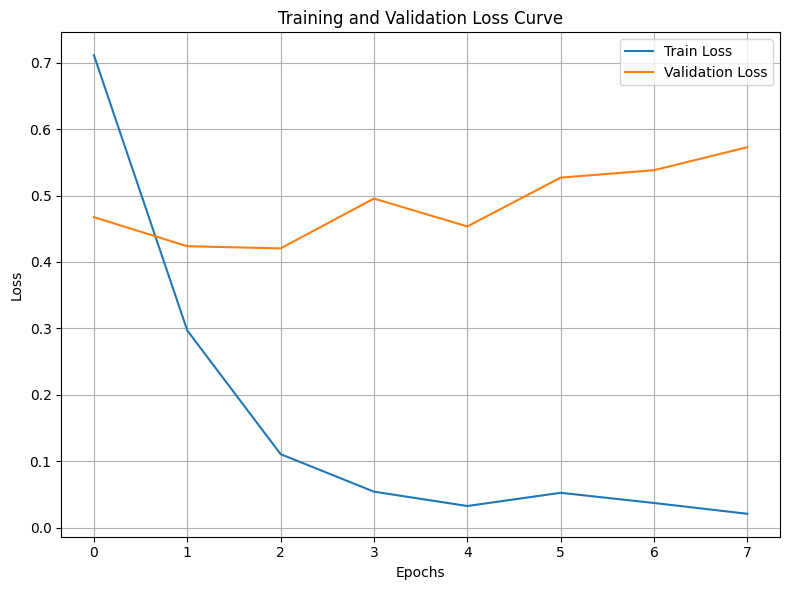

3-Class Sentiment Accuracy: 0.8576


In [33]:
# ==================== #
# STEP 8: RUN FULL FLOW #
# ==================== #
train_model(model, train_loader, val_loader, epochs=10)
evaluate_and_remap(model, test_loader, dataset)